## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [7]:
import pandas as pd

df = pd.read_csv("golub.csv")

df['target'] = df['cancer'].replace({
    'allB': 0,
    'allT': 0,
    'aml': 1
})

X = df.drop(columns=['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'target'])
y = df['target']

print(X.shape)
print(y.value_counts())

(72, 7129)
target
0    47
1    25
Name: count, dtype: int64


/tmp/ipykernel_35075/2715938060.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['target'] = df['cancer'].replace({


Training MSE: 1.2522824482837894e-30


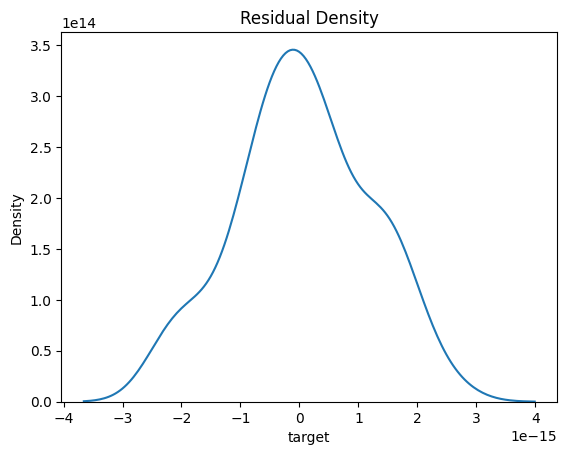

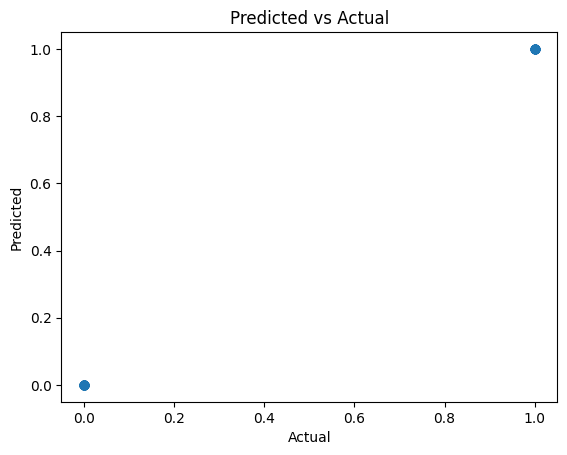

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)

mse = mean_squared_error(y, y_pred)
print("Training MSE:", mse)

residuals = y - y_pred

sns.kdeplot(residuals)
plt.title("Residual Density")
plt.show()

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score

mse_cv = -cross_val_score(lr, X, y, cv=5, scoring='neg_mean_squared_error')
print("Cross-validated MSE:", mse_cv.mean())

Cross-validated MSE: 0.06012309872062149


3. The model has an almost zero training MSE of 1.25*10^-30, but the cross-validated MSE is much higher at 0.0601. This gap clearly shows overfitting.
From a bias–variance perspective, the model has very low bias but extremely high variance. It fits the training data perfectly because there are far more features (7000 genes) than observations (72 patients), but it fails to generalize to new data. In short, the model is too flexible as it stores instead of learning real patterns, which is why performance drops under cross-validation.

Selected genes: Index(['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at',
       'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at',
       'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at',
       'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at',
       'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at',
       'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at',
       'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at',
       'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at'],
      dtype='object')
Number selected: 34
Discarded: 7095


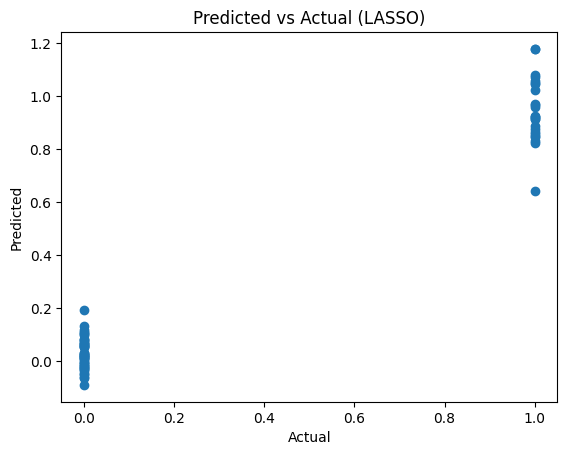

In [11]:
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X, y)

y_pred_lasso = lasso.predict(X)

selected_genes = X.columns[lasso.coef_ != 0]

print("Selected genes:", selected_genes)
print("Number selected:", len(selected_genes))
print("Discarded:", X.shape[1] - len(selected_genes))

plt.scatter(y, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (LASSO)")
plt.show()

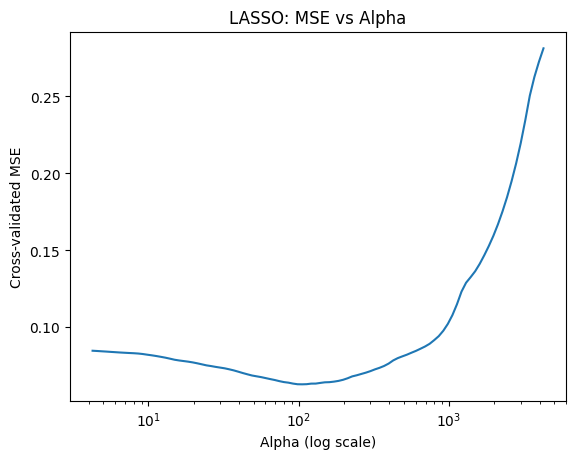

Optimal alpha: 105.24436668425457


In [12]:
import matplotlib.pyplot as plt
import numpy as np

alphas = lasso.alphas_
mse_path = lasso.mse_path_.mean(axis=1)

order = np.argsort(alphas)
alphas_sorted = alphas[order]
mse_sorted = mse_path[order]

plt.plot(alphas_sorted, mse_sorted)
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Cross-validated MSE")
plt.title("LASSO: MSE vs Alpha")
plt.show()

print("Optimal alpha:", lasso.alpha_)

5. Around 10^3 and above is underfitting, overfitting is around 10^1 and below, optimal is around 105.244.

6. Linear regression fits the training data perfectly because there are way more features than observations, so it basically memorizes the data. LASSO adds a penalty that keeps only the most important genes, which prevents overfitting. It doesn’t fit the training data perfectly, but it makes better predictions on new data.

7. Regularization works well in precision health because there are usually many features (like thousands of genes) but very few samples. It helps by reducing noise and focusing only on the most important variables, which makes the model more stable and better at predicting new patients.

8. LASSO can be risky in precision health because the features it selects may not be truly causal as they might just be correlated. This can lead to incorrect conclusions and potentially harmful treatment decisions.
It can also be unstable, meaning small changes in the data might lead to a different set of selected genes. In high-stakes settings like healthcare, this lack of reliability can be dangerous.